### **Part 1 - Definition and Visualization of Geometric Brownian Motion**

**Motivation:**  
Standard Brownian motion $W_t$ can take any value on $\mathbb{R}$, including negative values. We need a process that is always positive for asset pricing.

**Geometric Brownian Motion (GBM)** is defined by the stochastic differential equation (SDE):
$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t
$$

where:
- $S_t$ — asset price at time $t$
- $\mu$ — **drift**: the expected instantaneous return (annualized)
- $\sigma$ — **volatility**: the magnitude of random fluctuations (annualized)
- $W_t$ — standard Brownian motion
- $\mu S_t \, dt$ - **drift term**: no randomness, exponential growth
- $\sigma S_t \, dW_t$ - **diffusion term**: fluctuation is positively associated with price.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.prop_cycle': plt.cycler(color=[
        '#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'
    ]),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size': 12,
})

np.random.seed(42)

Solving with Itô's Lemma, we get the exact solution to Geometric Brownian Motion:
$$
{S_t = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]}
$$

This formula shows that the price process $S_t$ is an exponential transformation of Brownian motion.

Taking logs gives:

$$
\log\frac{S_t}{S_0}
=
\left(\mu-\frac12\sigma^2\right)t
+
\sigma W_t
$$

Therefore, the log-normalized GBM path is a Brownian motion with drift and volatility scaling.

In the plot below, we compare the Brownian motion path $W_t$ with the log-normalized GBM path $\log(S_t/S_0)$.  
They are not exactly the same because the log-GBM path includes the drift term and is scaled by $\sigma$, but they share the same underlying Brownian randomness.

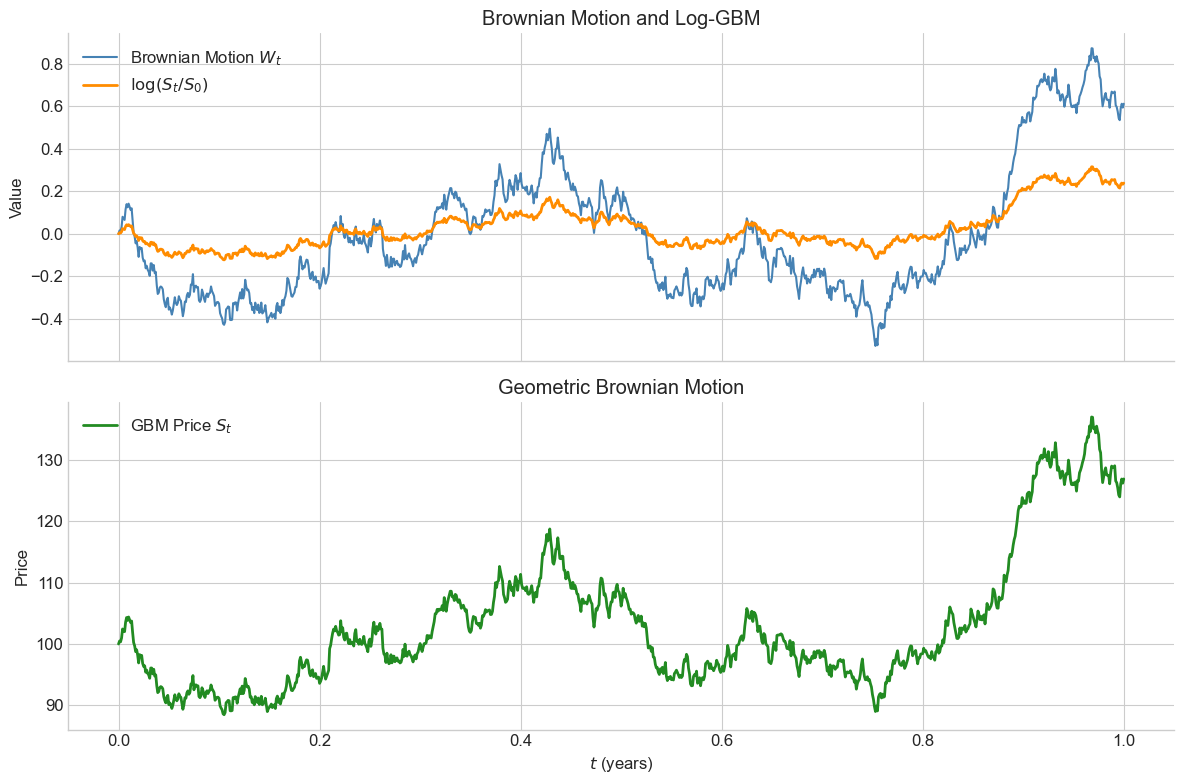

In [2]:
def simulate_gbm_exact(S0, mu, sigma, T, n_steps, n_paths, seed=None):
    # t : (n_steps+1,) time grid
    # paths : (n_paths, n_steps+1) price paths
    if seed is not None:
        np.random.seed(seed)
    dt = T / n_steps
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, n_steps))
    W = np.hstack([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)])
    t = np.linspace(0, T, n_steps + 1)
    paths = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    return t, W, paths
    
# Parameters    
S0 = 100
mu = 0.10
sigma = 0.30
T = 1.0
n_steps = 1000
n_paths = 1

# Simulate
t, W, S = simulate_gbm_exact(S0, mu, sigma, T, n_steps=n_steps, n_paths=n_paths, seed=42)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: BM and log-GBM
axes[0].plot(t, W[0], color='steelblue', linewidth=1.5, label=r'Brownian Motion $W_t$')

axes[0].plot(t, np.log(S[0] / S0), color='darkorange', linewidth=2, label=r'$\log(S_t/S_0)$')

axes[0].set_ylabel('Value')
axes[0].set_title('Brownian Motion and Log-GBM')
axes[0].legend()

# Bottom: GBM
axes[1].plot(t, S[0], color='forestgreen', linewidth=2, label=r'GBM Price $S_t$')

axes[1].set_xlabel('$t$ (years)')
axes[1].set_ylabel('Price')
axes[1].set_title('Geometric Brownian Motion')
axes[1].legend()
plt.tight_layout()
plt.show()

**Effect of Drift $\mu$ and Volatility $\sigma$**

The two parameters of GBM have distinct roles:  
- **Drift $\mu$** shifts the expected trajectory upward or downward.
  $\mathbb{E}[S_t] = S_0 e^{\mu t}$, so higher $\mu$ means faster expected growth.
- **Volatility $\sigma$** controls the spread of paths around that trend.
  High $\sigma$ means paths spread out widely, the same expected value but
  drastically different outcomes.

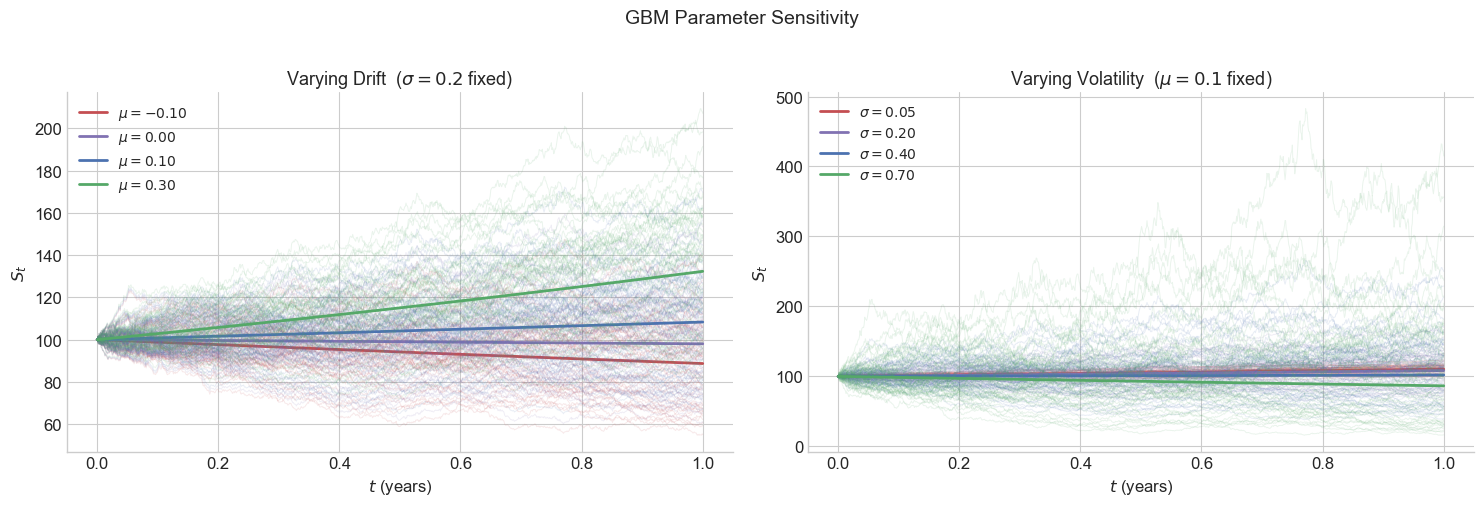

In [3]:
S0, T, n_steps, n_paths = 100, 1.0, 1000, 50
sigma_fixed = 0.20
mu_fixed = 0.10

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: vary drift
drifts = [-0.10, 0.00, 0.10, 0.30]
colors = ['#C44E52', '#8172B2', '#4C72B0', '#55A868']

for mu_, col in zip(drifts, colors):
    t, _, paths = simulate_gbm_exact(S0, mu_, sigma_fixed, T, n_steps, n_paths, seed=42)
    for path in paths:
        axes[0].plot(t, path, color=col, alpha=0.12, linewidth=0.7)
    # Plot median path (exp of mean log-price)
    median_path = S0 * np.exp((mu_ - 0.5*sigma_fixed**2) * t)
    axes[0].plot(t, median_path, color=col, linewidth=2.0,
                 label=f'$\\mu={mu_:.2f}$')

axes[0].set_xlabel('$t$ (years)')
axes[0].set_ylabel('$S_t$')
axes[0].set_title(f'Varying Drift  ($\\sigma={sigma_fixed}$ fixed)', fontsize=13)
axes[0].legend(fontsize=10)

# Right: vary volatility
vols = [0.05, 0.20, 0.40, 0.70]

for sigma_, col in zip(vols, colors):
    t, _, paths = simulate_gbm_exact(S0, mu_fixed, sigma_, T, n_steps, n_paths, seed=42)
    for path in paths:
        axes[1].plot(t, path, color=col, alpha=0.12, linewidth=0.7)
    median_path = S0 * np.exp((mu_fixed - 0.5*sigma_**2) * t)
    axes[1].plot(t, median_path, color=col, linewidth=2.0,
                 label=f'$\\sigma={sigma_:.2f}$')

axes[1].set_xlabel('$t$ (years)')
axes[1].set_ylabel('$S_t$')
axes[1].set_title(f'Varying Volatility  ($\\mu={mu_fixed}$ fixed)', fontsize=13)
axes[1].legend(fontsize=10)

fig.suptitle('GBM Parameter Sensitivity', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### **Part 2 - Comparison with Real Stock Data**  
Since $\log S_T = \log S_0 + (\mu - \sigma^2/2)T + \sigma W_T$ and
$W_T \sim \mathcal{N}(0, T)$, we have:
$$
\log S_T \sim \mathcal{N}\!\left(\log S_0 + \left(\mu - \frac{\sigma^2}{2}\right)T,\; \sigma^2 T\right)
$$
That is, $S_T$ is **lognormal distributed**.  

We verify this by comparing the empirical terminal distribution of $S_T$ across many simulated paths against the theoretical log-normal density. We need to calibrate GBM to real SPY data and overlay simulated paths against the actual price history.  

So, calibration is straightforward:
since log-returns are i.i.d. $\mathcal{N}((\mu - \sigma^2/2)\Delta t,\; \sigma^2 \Delta t)$,
we estimate:
$$
\hat{\sigma}^2 = \frac{\text{Var}(\log S_{t+1}/S_t)}{\Delta t}, \qquad
\hat{\mu} = \frac{\text{Mean}(\log S_{t+1}/S_t)}{\Delta t} + \frac{\hat{\sigma}^2}{2}
$$

We simulate 100 GBM paths and compare their median against real SPY data

Downloaded 1258 trading days, $296.89 → $577.70
Calibrated  μ = 0.1557  (15.6% annualized)
Calibrated  σ = 0.2108  (21.1% annualized)


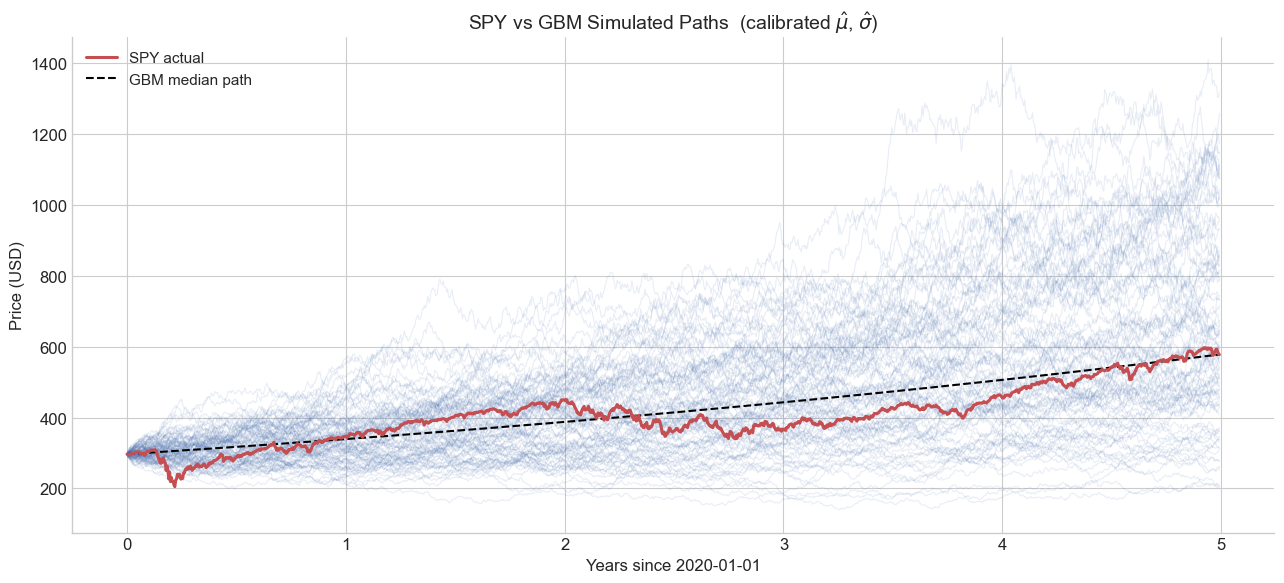

In [4]:
# Fetch SPY data
spy = yf.download('SPY', start='2020-01-01', end='2025-01-01',
                  auto_adjust=True, progress=False)

# Fix for newer yfinance versions returning MultiIndex columns
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.droplevel(1)

prices = spy['Close'].dropna().values
dates = spy['Close'].dropna().index

print(f"Downloaded {len(prices)} trading days, "
      f"${prices[0]:.2f} → ${prices[-1]:.2f}")

# Calibrate mu and sigma from log-returns
log_returns = np.diff(np.log(prices))
dt = 1/252
sigma_hat = log_returns.std()  / np.sqrt(dt)
mu_hat = log_returns.mean() / dt + 0.5 * sigma_hat**2

print(f"Calibrated  μ = {mu_hat:.4f}  ({mu_hat*100:.1f}% annualized)")
print(f"Calibrated  σ = {sigma_hat:.4f}  ({sigma_hat*100:.1f}% annualized)")

S0_real = prices[0]
T_real = len(prices) / 252
n_real = len(prices) - 1

t_sim, _, sim_paths = simulate_gbm_exact(S0_real, mu_hat, sigma_hat, T_real, n_steps=n_real, n_paths=100, seed=42)

t_axis = np.linspace(0, T_real, len(prices))

fig, ax = plt.subplots(figsize=(13, 6))
for path in sim_paths:
    ax.plot(t_axis, path, color='#4C72B0', alpha=0.12, linewidth=0.8)

ax.plot(t_axis, prices, color='#C44E52', linewidth=2.2,
        label='SPY actual', zorder=5)

median_path = S0_real * np.exp((mu_hat - 0.5*sigma_hat**2) * t_axis)
ax.plot(t_axis, median_path, color='black', linewidth=1.5,
        linestyle='--', label='GBM median path', zorder=4)

ax.set_xlabel('Years since 2020-01-01')
ax.set_ylabel('Price (USD)')
ax.set_title('SPY vs GBM Simulated Paths  (calibrated $\\hat{\\mu}$, $\\hat{\\sigma}$)',
             fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

If GBM were a perfect model, simulated paths would be exactly the same as the real path. We will see that they are not. we discuss several factors that may explain why the GBM model does not fully capture real market behavior.

**Failure 1: Non-normal (Fat Tails)**

GBM assumes log-returns are normally distributed. However, empirical return distributions exhibit:  
- **excess kurtosis** (fat tails): extreme moves happen far more often than the normal distribution predicts.
- **Negative skewness**: large down-moves are more common than large up-moves

We measure this with the **kurtosis** of daily log-returns:
$$
\text{Excess kurtosis} = \frac{\mathbb{E}[(r - \bar{r})^4]}{\sigma^4} - 3
$$

A normal distribution has excess kurtosis of exactly 0.

Excess kurtosis of SPY daily log-returns: 12.32  (normal = 0)


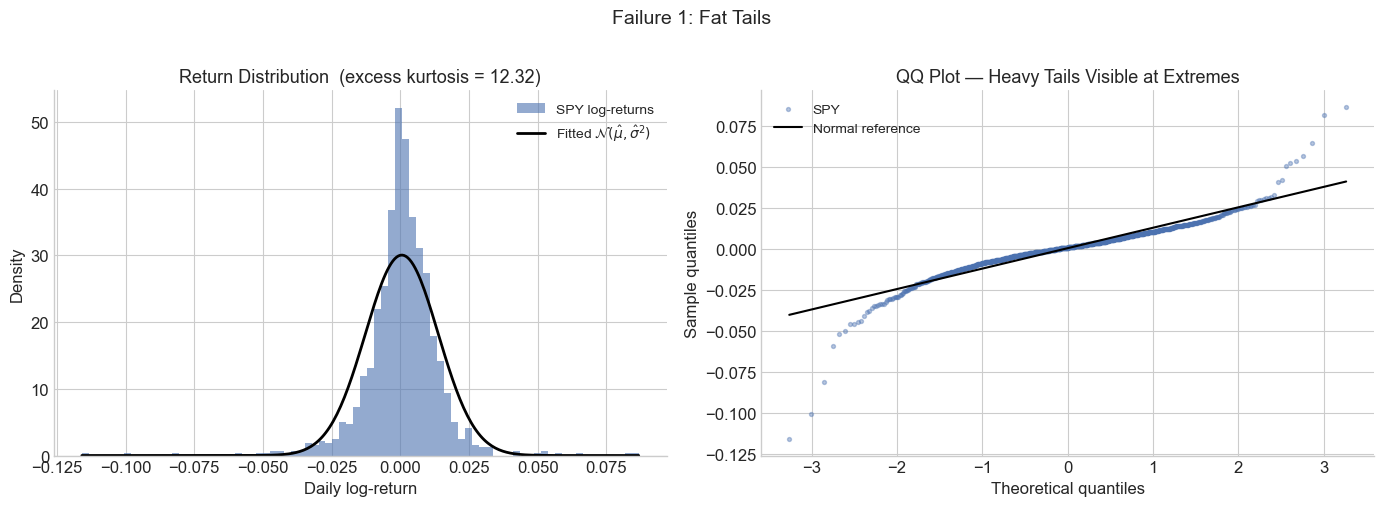

In [5]:
log_ret = np.diff(np.log(prices))
excess_kurt = stats.kurtosis(log_ret, fisher=True)  # Fisher = excess kurtosis
print(f"Excess kurtosis of SPY daily log-returns: {excess_kurt:.2f}  (normal = 0)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: empirical vs normal density
x_r = np.linspace(log_ret.min(), log_ret.max(), 300)
fitted_normal = stats.norm.pdf(x_r, loc=log_ret.mean(), scale=log_ret.std())

axes[0].hist(log_ret, bins=80, density=True, alpha=0.6,
             color='#4C72B0', label='SPY log-returns')
axes[0].plot(x_r, fitted_normal, 'k-', linewidth=2,
             label='Fitted $\\mathcal{N}(\\hat{\\mu}, \\hat{\\sigma}^2)$')
axes[0].set_xlabel('Daily log-return')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Return Distribution  (excess kurtosis = {excess_kurt:.2f})',
                  fontsize=13)
axes[0].legend(fontsize=10)

# Right: QQ plot
(osm, osr), (slope, intercept, _) = stats.probplot(log_ret, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=8, color='#4C72B0', label='SPY')
axes[1].plot(osm, slope*np.array(osm) + intercept, 'k-',
             linewidth=1.5, label='Normal reference')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')
axes[1].set_title('QQ Plot — Heavy Tails Visible at Extremes', fontsize=13)
axes[1].legend(fontsize=10)

fig.suptitle('Failure 1: Fat Tails', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Failure 2: Volatility Clustering**  
GBM assumes **constant volatility**: volatility parameter $\sigma$ is fixed over time.

In real financial markets, however, volatility is not constant. Instead, volatility tends to cluster: calm periods are followed by calm periods, while turbulent periods are followed by turbulent periods.

This phenomenon is known as **volatility clustering** and is one of the main empirical features of financial time series. 

**Failure 3: Autocorrelation in return and volatility**  
GBM assumes **independent increments**: past returns carry no information about future returns.

In practice, however, Raw returns may show short-term momentum or mean-reversion effects. And squared returns show significant positive autocorrelation, which is known as ARCH/GARCH effects.

**Failure 4: Jumps**  
GBM generates **continuous paths**. Real prices exhibit **sudden jumps** driven by macro shocks, earnings surprises, or geopolitical events. 

## Summary

| Property | GBM $S_t$ |
|---|---|
| SDE | $dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$ |
| Exact solution | $S_t = S_0 \exp\!\left[(\mu - \sigma^2/2)t + \sigma W_t\right]$ |
| Distribution of $S_T$ | Log-normal |
| Distribution of $\log S_T$ | $\mathcal{N}\!\left(\log S_0 + (\mu-\sigma^2/2)T,\; \sigma^2 T\right)$ |
| $\mathbb{E}[S_T]$ | $S_0 e^{\mu T}$ |
| Always positive? | Yes |